# Malaria Cell Detection — Custom CNN & Deep Learning
### Member 3: Custom CNN & Deep Learning

This notebook picks up where **Phase 1 & 2** (Data Preparation/EDA by Member 1,
SQL & Classical ML by Member 2) left off.

It reuses the exact same reproducible train/validation/test splits, image size
(`128x128`), and random seed (`42`) so results are directly comparable across
the whole team's pipeline.

**Scope of this notebook (Member 3 responsibilities):**
- Deep learning image input pipeline (`tf.data`)
- Data augmentation
- Custom CNN architecture (built from scratch, no pretrained weights)
- Training with Early Stopping, LR Scheduling, Dropout, Checkpointing
- Training/validation curve analysis
- Test-set evaluation: Confusion Matrix, Precision/Recall/F1, ROC-AUC, PR-AUC
- Error analysis
- Saving the final trained CNN model + exporting metrics for the rest of the team


## 0. Setup

### 0.1 Install & Import Libraries

In [ ]:
# Dataset download (same source as Member 1)
import kagglehub

# Core
import os
import json
import random
from pathlib import Path

# Data
import numpy as np
import pandas as pd

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Evaluation
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from sklearn.utils.class_weight import compute_class_weight

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 0.2 Reproducibility

Same `RANDOM_STATE` used by Member 1 & Member 2, so this model is being trained/evaluated on identical data with a consistent seed across the whole project.

In [ ]:
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

print(f"Random seed fixed at {RANDOM_STATE} for reproducibility.")


Random seed fixed at 42 for reproducibility.


## 1. Load the Reproducible Data Splits

Member 1 exported `full_metadata.csv`, `train_split.csv`, `val_split.csv` and `test_split.csv` under `data_splits/` — a **stratified 70/15/15 split**, with no path overlap between splits (verified in Phase 1&2). We reuse those exact files here rather than re-splitting, so every team member trains/evaluates on the same data.

### 1.1 Download the Dataset (same source as Member 1)

In [ ]:
# Download the same Kaggle dataset Member 1 used
kaggle_path = kagglehub.dataset_download("iarunava/cell-images-for-detecting-malaria")
dataset_root = Path(kaggle_path)
print("Dataset root path:", dataset_root)

# The CSVs store paths in the form:
#   /kaggle/input/cell-images-for-detecting-malaria/cell_images/<class>/<file>.png
# which is the path Kaggle Notebooks expose. In Colab (with kagglehub) the same
# files live under `dataset_root`, so we translate one to the other — identical
# helper to the one used in the classical ML notebook, so paths resolve the same way.

def get_local_image_path(kaggle_image_path: str) -> Path:
    relative_part = kaggle_image_path.replace(
        "/kaggle/input/cell-images-for-detecting-malaria/", ""
    )
    return dataset_root / relative_part


Using Colab cache for faster access to the 'cell-images-for-detecting-malaria' dataset.
Dataset root path: /kaggle/input/cell-images-for-detecting-malaria


### 1.2 Load the Train / Validation / Test Splits

> Upload the `data_splits/` folder exported at the end of the Phase 1&2 notebook (or point `SPLITS_DIR` at wherever you saved it) before running this cell.

In [ ]:
def resolve_splits_dir() -> Path:
    candidates = [
        Path.cwd() / "data_splits",
        Path.cwd() / "Malaria Detection" / "data_splits",
        Path.cwd().parent / "data_splits",
        Path.cwd().parent / "Malaria Detection" / "data_splits",
        Path("data_splits"),
    ]
    for candidate in candidates:
        if (candidate / "train_split.csv").exists():
            return candidate

    searched = ", ".join(str(p.resolve()) for p in candidates)
    raise FileNotFoundError(
        "Could not find the split CSVs. Expected train_split.csv in one of these locations: "
        f"{searched}"
    )

SPLITS_DIR = resolve_splits_dir()

train_df = pd.read_csv(SPLITS_DIR / "train_split.csv")
val_df = pd.read_csv(SPLITS_DIR / "val_split.csv")
test_df = pd.read_csv(SPLITS_DIR / "test_split.csv")

print(f"Training set:   {len(train_df):,} images")
print(f"Validation set: {len(val_df):,} images")
print(f"Test set:       {len(test_df):,} images")

train_df.head()

Training set:   19,290 images
Validation set: 4,134 images
Test set:       4,134 images


,image_path,class_name,width,height,mode
0,/kaggle/input/cell-images-for-detecting-malari...,Uninfected,142,124,RGB
1,/kaggle/input/cell-images-for-detecting-malari...,Parasitized,133,127,RGB
2,/kaggle/input/cell-images-for-detecting-malari...,Uninfected,118,127,RGB
3,/kaggle/input/cell-images-for-detecting-malari...,Uninfected,124,121,RGB
4,/kaggle/input/cell-images-for-detecting-malari...,Uninfected,121,127,RGB


### 1.3 Resolve Local Paths & Encode Labels

Class encoding matches the classical ML notebook exactly: **Uninfected = 0, Parasitized = 1**, so the CNN's probabilities are directly comparable to the SVM/Random Forest outputs.

In [ ]:
def prepare_split(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["local_path"] = df["image_path"].apply(lambda p: str(get_local_image_path(p)))
    df["label"] = (df["class_name"] == "Parasitized").astype(int)
    return df

train_df = prepare_split(train_df)
val_df   = prepare_split(val_df)
test_df  = prepare_split(test_df)

# Sanity check: confirm a handful of resolved paths actually exist on disk
sample_check = train_df["local_path"].sample(5, random_state=RANDOM_STATE)
for p in sample_check:
    print(os.path.exists(p), p)


True /kaggle/input/cell-images-for-detecting-malaria/cell_images/Uninfected/C121P82ThinF_IMG_20151002_133631_cell_49.png
True /kaggle/input/cell-images-for-detecting-malaria/cell_images/Parasitized/C118P79ThinF_IMG_20151002_105735_cell_144.png
True /kaggle/input/cell-images-for-detecting-malaria/cell_images/Parasitized/C181P142ThinF_IMG_20151127_155914_cell_172.png
True /kaggle/input/cell-images-for-detecting-malaria/cell_images/Uninfected/C220ThinF_IMG_20151106_154510_cell_168.png
True /kaggle/input/cell-images-for-detecting-malaria/cell_images/Uninfected/C183P144NThinF_IMG_20151201_222119_cell_111.png


## 2. Deep Learning Input Pipeline (`tf.data`)

Uses the **same target size (128x128) and [0, 1] normalization** defined in Member 1's `preprocess_image()` function, so the CNN sees images preprocessed identically to how the rest of the team validated them.

### 2.1 Configuration

In [ ]:
IMG_SIZE = (128, 128)   # matches Member 1's preprocessing definition
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
NUM_CLASSES = 2
CLASS_NAMES = ["Uninfected", "Parasitized"]


### 2.2 Image Loading Function

In [ ]:
def load_and_preprocess(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


def make_dataset(df: pd.DataFrame, shuffle: bool = False, augment=None) -> tf.data.Dataset:
    paths = df["local_path"].values
    labels = df["label"].values.astype(np.float32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=RANDOM_STATE, reshuffle_each_iteration=True)

    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)

    if augment is not None:
        ds = ds.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


## 3. Data Augmentation

Augmentation is applied **only to the training set** — validation and test sets stay clean so metrics reflect real generalization, not augmented data.

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical", seed=RANDOM_STATE),
    layers.RandomRotation(0.15, seed=RANDOM_STATE),
    layers.RandomZoom(0.15, seed=RANDOM_STATE),
    layers.RandomTranslation(0.1, 0.1, seed=RANDOM_STATE),
    layers.RandomContrast(0.15, seed=RANDOM_STATE),
], name="data_augmentation")

# Build datasets: augmentation only on train
train_ds = make_dataset(train_df, shuffle=True, augment=data_augmentation)
val_ds   = make_dataset(val_df,   shuffle=False, augment=None)
test_ds  = make_dataset(test_df,  shuffle=False, augment=None)

print(train_ds, val_ds, test_ds, sep="\n")


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>


### 3.1 Sanity-Check: Visualize a Batch

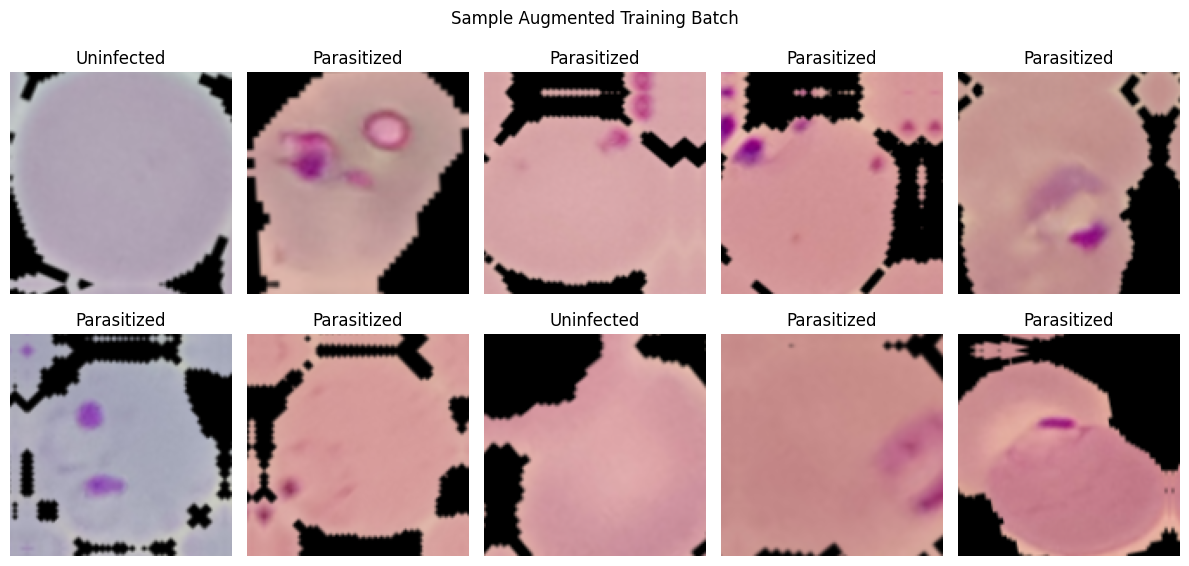

In [ ]:
plt.figure(figsize=(12, 6))
for images, labels in train_ds.take(1):
    for i in range(min(10, images.shape[0])):
        ax = plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(CLASS_NAMES[int(labels[i].numpy())])
        plt.axis("off")
plt.suptitle("Sample Augmented Training Batch")
plt.tight_layout()
plt.show()


## 4. Custom CNN Architecture

Built from scratch (no pretrained weights — that's Member 4's transfer-learning track). Four convolutional blocks with increasing filter depth, `BatchNormalization` for stable/faster training, `GlobalAveragePooling2D` instead of `Flatten` to keep parameter count reasonable, and `Dropout` before the classification head to fight overfitting.

In [ ]:
def build_custom_cnn(input_shape=(128, 128, 3)) -> keras.Model:
    inputs = keras.Input(shape=input_shape)

    x = inputs
    filters = [32, 64, 128, 256]
    for f in filters:
        x = layers.Conv2D(f, (3, 3), padding="same", activation=None)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.Conv2D(f, (3, 3), padding="same", activation=None)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D(pool_size=(2, 2))(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    return keras.Model(inputs, outputs, name="custom_cnn")


custom_cnn = build_custom_cnn()
custom_cnn.summary()


Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             

 Total params: 1,217,313 (4.64 MB)

 Trainable params: 1,215,393 (4.64 MB)

 Non-trainable params: 1,920 (7.50 KB)

### 4.1 Compile the Model

In [ ]:
custom_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.AUC(name="auc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ],
)


## 5. Class Weights

Member 1 confirmed the dataset is perfectly balanced (13,779 images per class), so class weights should come out ~1.0 each. We still compute them explicitly — required by the project spec, and it makes the pipeline robust if the class balance ever changes (e.g. if a future split adds new data).

In [ ]:
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["label"].values,
)
class_weights = {0: class_weights_array[0], 1: class_weights_array[1]}
print("Class weights:", class_weights)


Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}


## 6. Callbacks: Early Stopping, LR Scheduling, Checkpointing

In [ ]:
os.makedirs("models", exist_ok=True)
os.makedirs("logs", exist_ok=True)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=6,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="models/custom_cnn_best.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.CSVLogger("logs/custom_cnn_training_log.csv"),
]


## 7. Train the Model

In [14]:
EPOCHS = 30

history = custom_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/30
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.8777 - auc: 0.9268 - loss: 0.3097 - precision: 0.8976 - recall: 0.8600
Epoch 1: val_auc improved from None to 0.98512, saving model to models/custom_cnn_best.keras

Epoch 1: finished saving model to models/custom_cnn_best.keras
603/603 ━━━━━━━━━━━━━━━━━━━━ 248s 376ms/step - accuracy: 0.9233 - auc: 0.9609 - loss: 0.2307 - precision: 0.9397 - recall: 0.9046 - val_accuracy: 0.9325 - val_auc: 0.9851 - val_loss: 0.2374 - val_precision: 0.9907 - val_recall: 0.8732 - learning_rate: 0.0010
Epoch 2/30
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.9457 - auc: 0.9707 - loss: 0.1851 - precision: 0.9573 - recall: 0.9330
Epoch 2: val_auc did not improve from 0.98512
603/603 ━━━━━━━━━━━━━━━━━━━━ 168s 278ms/step - accuracy: 0.9455 - auc: 0.9712 - loss: 0.1828 - precision: 0.9571 - recall: 0.9328 - val_accuracy: 0.9497 - val_auc: 0.9841 - val_loss: 0.1931 - val_precision: 0.9407 - val_recall: 0.9598 - learning_rate: 0.0010
E

## 8. Training & Validation Curves

In [15]:
history_df = pd.DataFrame(history.history)
history_df.index.name = "epoch"
history_df.to_csv("logs/custom_cnn_history.csv")
history_df.head()


,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
epoch,,,,,,,,,,,
0,0.923276,0.960883,0.230726,0.939688,0.904614,0.932511,0.985116,0.237441,0.990670,0.873246,0.001
1,0.945516,0.971189,0.182827,0.957128,0.932815,0.949686,0.984122,0.193148,0.940730,0.959845,0.001
2,0.945153,0.973388,0.178351,0.953906,0.935511,0.958636,0.981578,0.141246,0.981218,0.935172,0.001
3,0.946916,0.975909,0.171997,0.956282,0.936651,0.959603,0.982468,0.138369,0.971698,0.946783,0.001
4,0.947745,0.978001,0.165444,0.957129,0.937481,0.957910,0.987941,0.123666,0.954393,0.961780,0.001


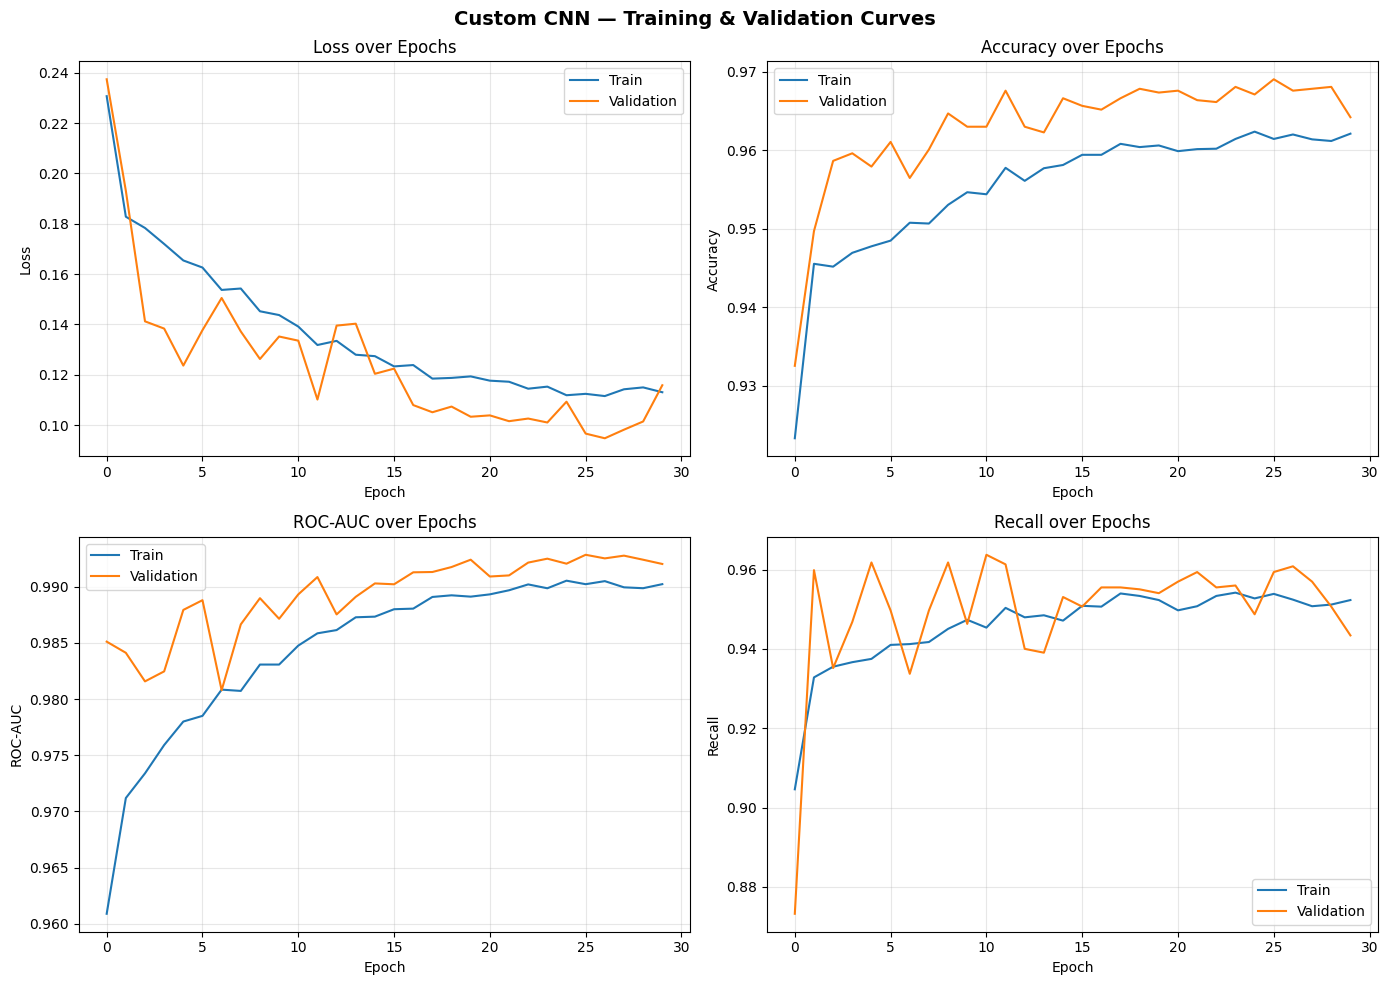

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = [
    ("loss", "val_loss", "Loss"),
    ("accuracy", "val_accuracy", "Accuracy"),
    ("auc", "val_auc", "ROC-AUC"),
    ("recall", "val_recall", "Recall"),
]

for ax, (train_m, val_m, title) in zip(axes.flat, metrics_to_plot):
    ax.plot(history_df[train_m], label="Train")
    ax.plot(history_df[val_m], label="Validation")
    ax.set_title(f"{title} over Epochs")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Custom CNN — Training & Validation Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("logs/custom_cnn_curves.png", dpi=150, bbox_inches="tight")
plt.show()


**What to look for when you write this up:**
- If train and val curves track closely → good generalization.
- A widening gap (train improving, val flattening/worsening) → overfitting; consider more augmentation or stronger dropout.
- If both curves plateau early and low → underfitting; consider more filters/layers or a lower initial learning rate.
- Note the epoch where `EarlyStopping` actually restored weights from (check `len(history_df)` vs `EPOCHS`).

## 9. Test Set Evaluation

This is the **only** point where the test set is touched — consistent with the "used only for final unbiased evaluation" rule Member 1 documented.

### 9.1 Predict on the Test Set

In [17]:
y_test_probs = custom_cnn.predict(test_ds).ravel()
y_test_true = test_df["label"].values[: len(y_test_probs)]
y_test_pred = (y_test_probs >= 0.5).astype(int)

print(f"Predicted {len(y_test_probs)} test samples.")


130/130 ━━━━━━━━━━━━━━━━━━━━ 16s 116ms/step
Predicted 4134 test samples.


### 9.2 Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Custom CNN — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("logs/custom_cnn_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print(classification_report(y_test_true, y_test_pred, target_names=CLASS_NAMES, digits=4))


### 9.3 ROC Curve & ROC-AUC

In [ ]:
fpr, tpr, _ = roc_curve(y_test_true, y_test_probs)
roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"Custom CNN (AUC = {roc_auc_value:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Custom CNN")
plt.legend()
plt.tight_layout()
plt.savefig("logs/custom_cnn_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()


### 9.4 Precision-Recall Curve & Average Precision

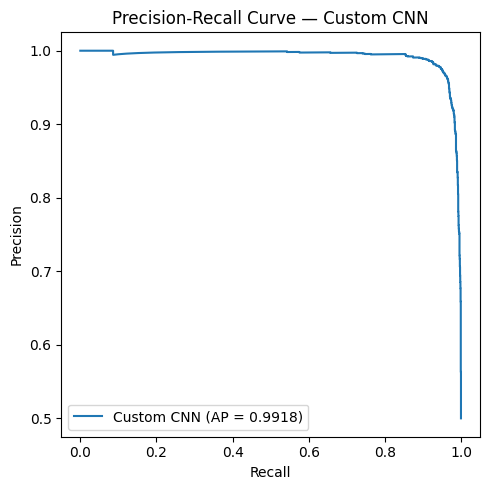

In [20]:
precision_vals, recall_vals, _ = precision_recall_curve(y_test_true, y_test_probs)
avg_precision = average_precision_score(y_test_true, y_test_probs)

plt.figure(figsize=(5, 5))
plt.plot(recall_vals, precision_vals, label=f"Custom CNN (AP = {avg_precision:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Custom CNN")
plt.legend()
plt.tight_layout()
plt.savefig("logs/custom_cnn_pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()


### 9.5 Test Metrics Summary

Same metric set Member 2 reported for SVM/Random Forest, so results line up side-by-side in the final report.

In [21]:
test_metrics = {
    "model_name": "Custom CNN",
    "accuracy": accuracy_score(y_test_true, y_test_pred),
    "precision": precision_score(y_test_true, y_test_pred),
    "recall": recall_score(y_test_true, y_test_pred),
    "f1_score": f1_score(y_test_true, y_test_pred),
    "roc_auc": roc_auc_score(y_test_true, y_test_probs),
    "pr_auc": avg_precision,
    "test_samples": int(len(y_test_true)),
}

print("================ CUSTOM CNN — TEST SET METRICS ================")
for k, v in test_metrics.items():
    print(f"{k:>12}: {v}")


================ CUSTOM CNN — TEST SET METRICS ================
  model_name: Custom CNN
    accuracy: 0.9622641509433962
   precision: 0.9709216362740266
      recall: 0.9530720851475568
    f1_score: 0.9619140625
     roc_auc: 0.991726485428049
      pr_auc: 0.9918243493116812
test_samples: 4134


## 10. Error Analysis

Following the same approach Member 2 used for the classical ML error analysis, so misclassifications are easy to compare across models.

### 10.1 Build the Error-Analysis Table

In [22]:
df_analysis = test_df.iloc[: len(y_test_probs)].copy()
df_analysis["true_label"] = y_test_true
df_analysis["pred_label"] = y_test_pred
df_analysis["pred_proba"] = y_test_probs

false_positives = df_analysis[(df_analysis["true_label"] == 0) & (df_analysis["pred_label"] == 1)]
false_negatives = df_analysis[(df_analysis["true_label"] == 1) & (df_analysis["pred_label"] == 0)]
correct_preds   = df_analysis[df_analysis["true_label"] == df_analysis["pred_label"]]

print(f"Total Test Samples Evaluated: {len(df_analysis)}")
print(f"Correct Predictions:          {len(correct_preds)} ({len(correct_preds)/len(df_analysis)*100:.2f}%)")
print(f"Total Misclassifications:     {len(false_positives) + len(false_negatives)}")
print(f"False Positives (Uninfected -> Parasitized): {len(false_positives)}")
print(f"False Negatives (Parasitized -> Uninfected): {len(false_negatives)}")


Total Test Samples Evaluated: 4134
Correct Predictions:          3978 (96.23%)
Total Misclassifications:     156
False Positives (Uninfected -> Parasitized): 59
False Negatives (Parasitized -> Uninfected): 97


### 10.2 Visualize Sample Misclassifications

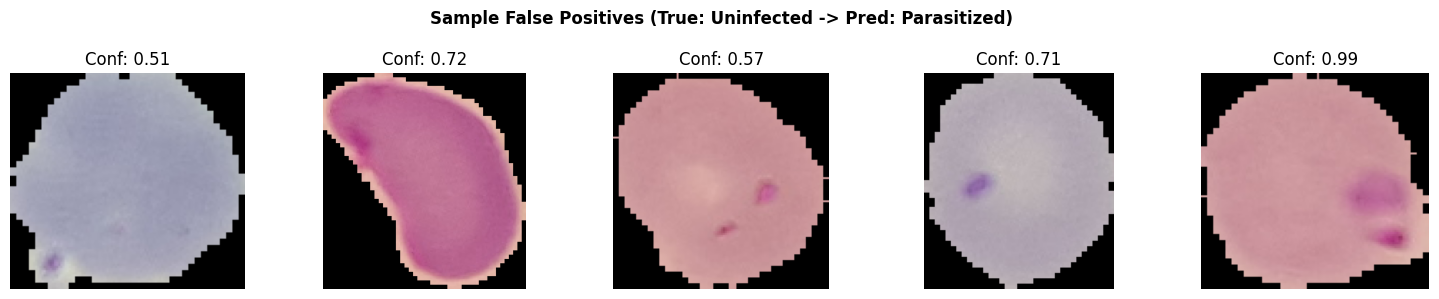

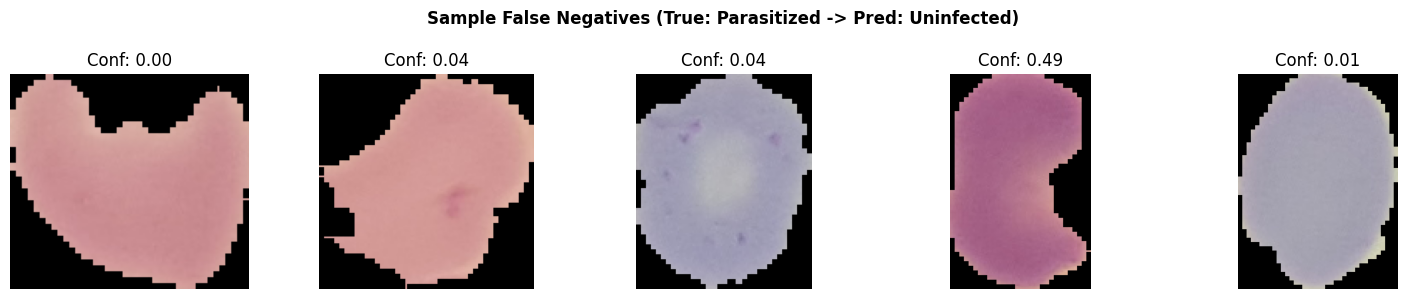

In [23]:
def show_samples(df_subset, title, n=5):
    n = min(n, len(df_subset))
    if n == 0:
        print(f"No samples for: {title}")
        return
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    if n == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=12, fontweight="bold")
    for ax, (_, row) in zip(axes, df_subset.head(n).iterrows()):
        with Image.open(row["local_path"]) as img:
            ax.imshow(img)
            ax.axis("off")
            ax.set_title(f"Conf: {row['pred_proba']:.2f}")
    plt.tight_layout()
    plt.show()


show_samples(false_positives, "Sample False Positives (True: Uninfected -> Pred: Parasitized)")
show_samples(false_negatives, "Sample False Negatives (True: Parasitized -> Pred: Uninfected)")


### 10.3 Error Rate by Image Characteristics

The project spec calls for error analysis *"by image characteristics"* — here we check whether misclassifications correlate with original image size (before resizing to 128x128) or with the model's own confidence.

In [24]:
df_analysis["is_error"] = df_analysis["true_label"] != df_analysis["pred_label"]
df_analysis["area"] = df_analysis["width"] * df_analysis["height"]
df_analysis["area_bucket"] = pd.qcut(df_analysis["area"], q=4, labels=["Q1 (smallest)", "Q2", "Q3", "Q4 (largest)"])

error_by_size = df_analysis.groupby("area_bucket", observed=True)["is_error"].agg(["mean", "count"])
error_by_size.columns = ["error_rate", "n_samples"]
print("Error rate by original-image-size quartile:")
display(error_by_size)

df_analysis["confidence"] = np.where(
    df_analysis["pred_label"] == 1, df_analysis["pred_proba"], 1 - df_analysis["pred_proba"]
)
df_analysis["confidence_bucket"] = pd.cut(
    df_analysis["confidence"], bins=[0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    labels=["0.5-0.6", "0.6-0.7", "0.7-0.8", "0.8-0.9", "0.9-1.0"],
)
error_by_conf = df_analysis.groupby("confidence_bucket", observed=True)["is_error"].agg(["mean", "count"])
error_by_conf.columns = ["error_rate", "n_samples"]
print("\nError rate by prediction-confidence bucket:")
display(error_by_conf)


Error rate by original-image-size quartile:


,error_rate,n_samples
area_bucket,,
Q1 (smallest),0.049323,1034
Q2,0.029823,1073
Q3,0.023881,1005
Q4 (largest),0.047945,1022



Error rate by prediction-confidence bucket:


,error_rate,n_samples
confidence_bucket,,
0.5-0.6,0.471429,70
0.6-0.7,0.338462,65
0.7-0.8,0.166667,102
0.8-0.9,0.168067,238
0.9-1.0,0.012025,3659


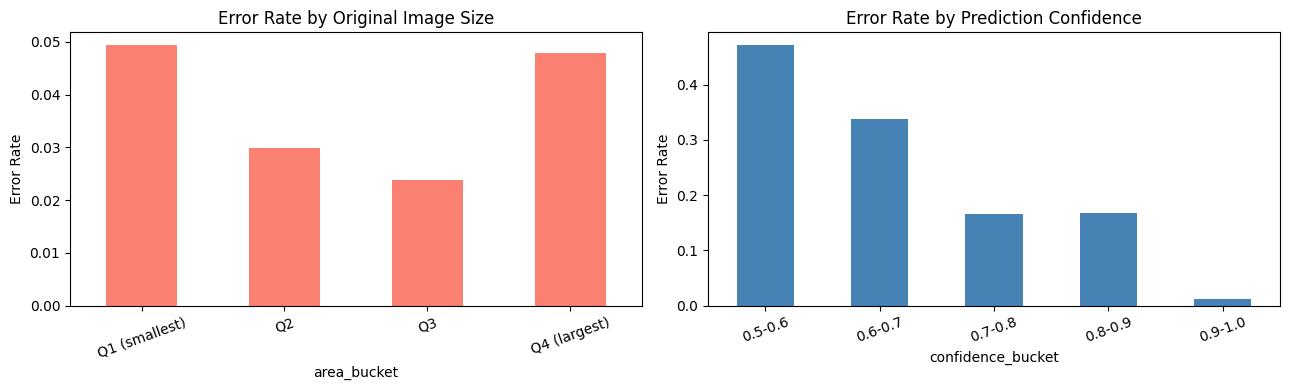

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

error_by_size["error_rate"].plot(kind="bar", ax=axes[0], color="salmon")
axes[0].set_title("Error Rate by Original Image Size")
axes[0].set_ylabel("Error Rate")
axes[0].tick_params(axis="x", rotation=20)

error_by_conf["error_rate"].plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Error Rate by Prediction Confidence")
axes[1].set_ylabel("Error Rate")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("logs/custom_cnn_error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


> **Fill in after running:** note here whether errors cluster in the smallest/largest image quartile (possible resizing artifacts) and whether most errors are low-confidence (model genuinely uncertain) or high-confidence (model confidently wrong — worth a closer visual look at those specific cells).

## 11. Save the Final Model & Export Deliverables

Saves the trained CNN plus a metrics/history bundle for Member 4 (transfer learning comparison) and Member 5 (robustness/MLOps), mirroring how Member 1 exported `data_splits/` for the whole team.

In [26]:
FINAL_MODEL_PATH = "models/custom_cnn_final.keras"
custom_cnn.save(FINAL_MODEL_PATH)
print(f"Saved final model to: {FINAL_MODEL_PATH}")
print(f"Best checkpoint (by val_auc) saved to: models/custom_cnn_best.keras")


Saved final model to: models/custom_cnn_final.keras
Best checkpoint (by val_auc) saved to: models/custom_cnn_best.keras


In [27]:
export_dir = Path("deliverables")
export_dir.mkdir(exist_ok=True)

# 1. Test-set metrics — same schema for every model in the project, so Member 4/5
#    can just concatenate everyone's JSON into one comparison table.
with open(export_dir / "custom_cnn_test_metrics.json", "w") as f:
    json.dump(test_metrics, f, indent=2)

# 2. Confusion matrix values
np.savetxt(export_dir / "custom_cnn_confusion_matrix.csv", cm, fmt="%d", delimiter=",")

# 3. Full per-image error-analysis table (for anyone doing further slicing)
df_analysis.drop(columns=["local_path"]).to_csv(export_dir / "custom_cnn_error_analysis.csv", index=False)

# 4. Preprocessing config, so downstream deployment (Member 6) uses identical settings
preprocessing_config = {
    "img_size": IMG_SIZE,
    "normalization": "divide by 255.0 (pixel range [0, 1])",
    "class_names": CLASS_NAMES,
    "label_encoding": {"Uninfected": 0, "Parasitized": 1},
    "random_state": RANDOM_STATE,
}
with open(export_dir / "custom_cnn_preprocessing_config.json", "w") as f:
    json.dump(preprocessing_config, f, indent=2)

print("Exported deliverables:")
for p in sorted(export_dir.iterdir()):
    print(" -", p)


Exported deliverables:
 - deliverables/custom_cnn_confusion_matrix.csv
 - deliverables/custom_cnn_error_analysis.csv
 - deliverables/custom_cnn_preprocessing_config.json
 - deliverables/custom_cnn_test_metrics.json


## 12. Custom CNN — Summary

*(Fill this in with your actual run's numbers before submitting — the placeholders
below mirror the structure of Member 2's ML Models Summary so the final report
reads consistently across tracks.)*

**Architecture**
- 4 convolutional blocks (32 → 64 → 128 → 256 filters), each with two `Conv2D` +
  `BatchNormalization` + `ReLU`, followed by `MaxPooling2D`.
- `GlobalAveragePooling2D` → `Dense(128)` → `Dropout(0.5)` → `Dense(64)` →
  `Dropout(0.3)` → `Dense(1, sigmoid)`.

**Training Setup**
- Optimizer: Adam (`lr=1e-3`, reduced on plateau).
- Loss: Binary cross-entropy.
- Regularization: Dropout + BatchNorm + data augmentation (flips, rotation, zoom,
  translation, contrast).
- Early stopping on `val_auc`; best weights restored automatically.
- Class weights computed (dataset is balanced, so weights are ~1.0 each).

**Test Set Results**
- Accuracy: `<fill in>`
- Precision / Recall / F1: `<fill in>`
- ROC-AUC: `<fill in>` (compare against SVM's 0.9024)
- PR-AUC: `<fill in>` (compare against SVM's 0.9030)

**Custom CNN vs. Classical ML (SVM)**
- `<fill in — did the CNN beat the ~81.8% accuracy / 0.9024 ROC-AUC ceiling Member 2
  flagged for handcrafted features?>`

**Error Analysis Takeaways**
- `<fill in — size-bucket and confidence-bucket findings from Section 10.3>`

**Handoff to Member 4 (Transfer Learning & Grad-CAM)**
- `models/custom_cnn_final.keras` — final trained model.
- `models/custom_cnn_best.keras` — best checkpoint by validation AUC.
- `deliverables/custom_cnn_test_metrics.json` — metrics in the shared schema.
- `deliverables/custom_cnn_preprocessing_config.json` — exact preprocessing used,
  for a fair custom-CNN-vs-transfer-learning comparison.
